# Explorative Datenanalyse und Clustering

Ziel der Übung ist es, die explorative Datenanalyse mit unbekannten Beispieldaten zu üben und im Anschluss gelernte Methoden des Clusterings auf diese Anzuwenden und zu visualisieren.

Bei der Erstellung dieses Notebooks wurde KI unterstützend für Formulierungen und Codevorschläge genutzt. Die fachliche Auswahl, Prüfung und Interpretation der Inhalte erfolgt manuell. Gegebene Vorlage wurde dann selbstständig weiter bearbeitet. Die Exploration und Clustering wurde ohne weitere Hilfe gemacht.

Ausgangsprompt: 
    Codex GPT 5.4 Mini, medium effort:  

    "schau in [clustering.ipynb](clustering.ipynb) und schreib mir eine Erklärung des "Wine recognition Dataset" inklusive code zu laden unter der "## Explorative Datenanlyse". Füge unter dem ersten absatz eine erklärung zur ki-nutzung hinzu."  

    "mache die erklärung des Datensatzes jetzt bitte ausführlicher. erkläre, was die einzelnen Features aussagen (erkläre es einem nicht-chemiker und nicht-wein-kenner)"

    "bitte füge auch erklärungen zu den Wertebereichen und einheiten in tabellarischer Darstellung hinzu (sofern bekannt!!)"

    Erweiterung des Notebooks durch: Varianzabdeckung durch PCA und Gegenüberstellung der k-Means cluster mit realen Clustern mit KI gemacht: "bitte bau in [clustering.ipynb](09/clustering.ipynb) die visualisierung des varianzverlustes und die gegenüberstellung der cluster mit den target-klassen in die diagramme"

## Explorative Datenanalyse

Der *Wine recognition Dataset* stammt aus dem UCI Machine Learning Repository und enthält Messwerte von Weinproben aus drei verschiedenen Rebsorten. Jede Zeile beschreibt eine Probe mit 13 Merkmalen. Diese Werte sind keine Geschmacksnoten, sondern objektive Labor-Messungen, mit denen sich Weine vergleichen lassen.

Einfach gesagt zeigen die Merkmale, wie „leicht“, „kräftig“, „fruchtig“, „farbintensiv“ oder „stoffig“ ein Wein ungefähr wirkt. Für die Analyse ist das nützlich, weil sich damit untersuchen lässt, ob Proben mit ähnlichen Eigenschaften auch zu ähnlichen Gruppen gehören.

Die 13 Merkmale im Überblick. Hinweis zu den Einheiten: Im Datensatz selbst sind für die meisten Merkmale keine expliziten physikalischen Einheiten dokumentiert. Es handelt sich um Laborwerte bzw. chemische Messgrößen; die angegebenen Bereiche sind die im Datensatz vorkommenden Beobachtungen. Wenn eine Einheit nicht bekannt ist, steht das ausdrücklich dabei.

| Merkmal | Bedeutung | Wertebereich im Datensatz | Einheit / Hinweis |
|---|---|---:|---|
| Alcohol | Wie viel Alkohol im Wein steckt. Höhere Werte bedeuten meist einen kräftigeren Wein. | ca. 11.03 bis 14.83 | Einheit nicht explizit dokumentiert; im Wein-Kontext wahrscheinlich Vol.-%, aber nur eine Interpretation. |
| Malic acid | Ein Säurebestandteil, der zu einer frischen oder eher säuerlichen Wahrnehmung beitragen kann. | ca. 0.74 bis 5.80 | Einheit nicht dokumentiert. |
| Ash | Der Mineralstoff- bzw. Aschegehalt. Das ist ein Hinweis auf die Rückstände aus den Trauben, kein Geschmackswert direkt. | ca. 1.36 bis 3.23 | Einheit nicht dokumentiert. |
| Alcalinity of ash | Wie „basisch“ die Asche ist. Ein Laborwert, der etwas über die chemische Zusammensetzung aussagt. | ca. 10.6 bis 30.0 | Einheit nicht dokumentiert. |
| Magnesium | Gehalt an Magnesium im Wein. Das ist ein Mineralstoffwert und Teil der chemischen Zusammensetzung. | ca. 70 bis 162 | Einheit nicht dokumentiert. |
| Total phenols | Gesamtmenge an Phenolen. Das sind Stoffe, die oft mit Struktur, Bitterkeit und Reife zusammenhängen. | ca. 0.98 bis 3.88 | Einheit nicht dokumentiert. |
| Flavanoids | Eine wichtige Untergruppe der Phenole. Sie beeinflussen häufig Farbe, Bitterkeit und den Gesamteindruck. | ca. 0.34 bis 5.08 | Einheit nicht dokumentiert. |
| Nonflavanoid phenols | Phenole, die nicht zu den Flavonoiden gehören. Ebenfalls chemische Begleitstoffe, die den Charakter mitprägen. | ca. 0.13 bis 0.66 | Einheit nicht dokumentiert. |
| Proanthocyanins | Stoffe, die zu einem adstringierenden, also leicht „zusammenziehenden“ Mundgefühl beitragen können. | ca. 0.41 bis 3.58 | Einheit nicht dokumentiert. |
| Color intensity | Wie kräftig die Farbe des Weins ist. Das ist oft ein guter Hinweis auf die optische Erscheinung und mögliche Stilunterschiede. | ca. 1.28 bis 13.0 | Einheit nicht dokumentiert. |
| Hue | Der Farbton. Vereinfacht gesagt: ob die Farbe eher rötlich, bräunlich oder anders wirkt. | ca. 0.48 bis 1.71 | Einheit nicht dokumentiert. |
| OD280/OD315 of diluted wines | Ein Messwert zur Lichtabsorption. Für Nicht-Chemiker kann man ihn als Laborindikator für bestimmte Inhaltsstoffe verstehen. | ca. 1.27 bis 4.00 | Einheit nicht dokumentiert. |
| Proline | Eine Aminosäure. Der Wert ist ein weiterer chemischer Hinweis auf die Zusammensetzung des Weins. | ca. 278 bis 1680 | Einheit nicht dokumentiert. |

Für die explorative Datenanalyse ist der Datensatz gut geeignet, weil er übersichtlich ist, keine fehlenden Werte enthält und sich Struktur sowie mögliche Gruppenbildung direkt untersuchen und dann mit dem Label "target" als Zielvariable überprüfen lassen.

In [30]:
from sklearn.datasets import load_wine

import pandas as pd

# Wine recognition Dataset laden und als DataFrame bereitstellen.
wine = load_wine(as_frame=True)
df_wine = wine.frame.copy()

df_wine.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [31]:
df_wine.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

Die Daten sind soweit vollständig und vollkommen numerisch. 

In [32]:
df_wine.describe(percentiles=[])


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Hier zeigt sich, dass die Daten verschiedene Wertebereiche haben und zur sicherheit vor dem Fitten von Modellen entsprechend skaliert werden sollten.

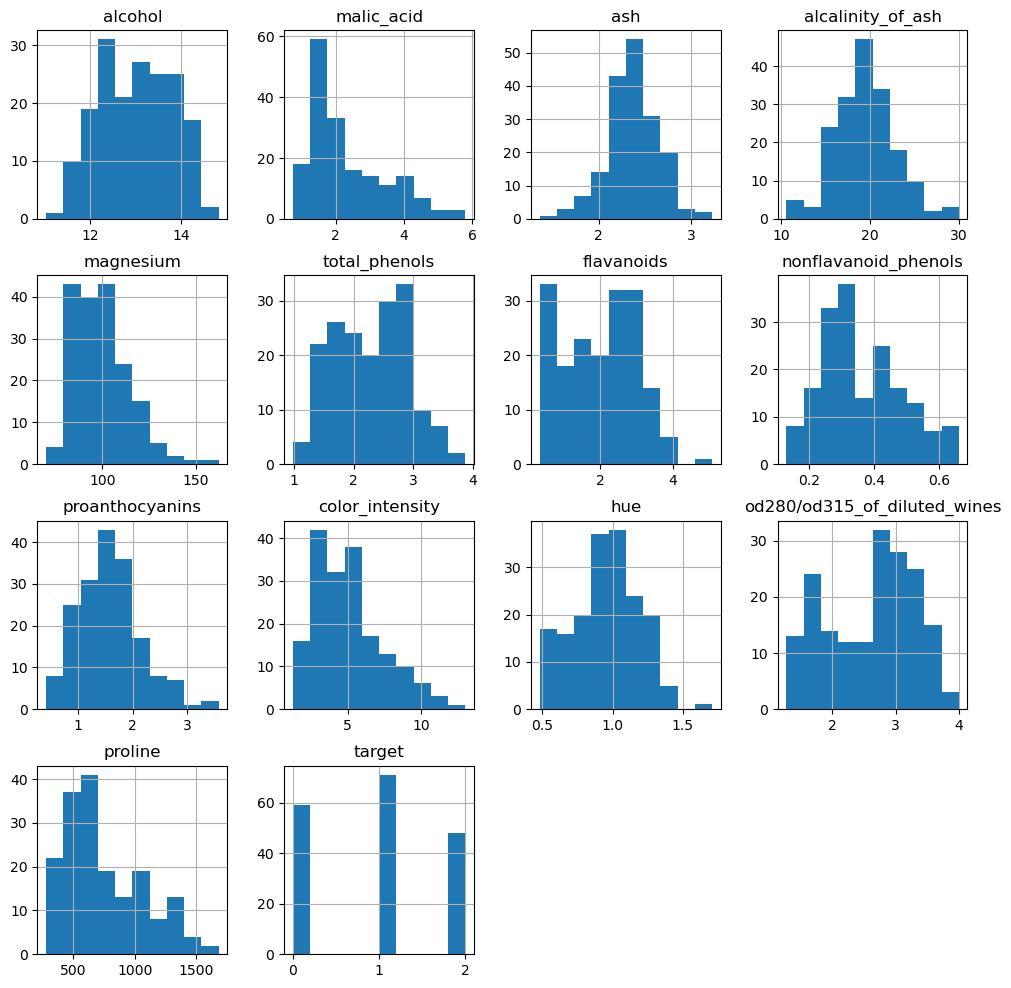

In [33]:
import matplotlib.pyplot as plt

df_wine.hist(figsize=(12,12))
plt.show()


Aus den Verteilungen der einzelnen Graphen lassen sich die drei Zielgruppen nicht offensichtlich ablesen. Es gibt aber klare Grüppchen-Bildung in verschiedenen Merkmalen. Beim Merkmal "flavanoids" oder "od280/od315_of_diluted_wines" sieht man das deutlich.

## One-Hot-Encoding

Um die Korrelationen von Features mit einzelnen Klassen besser berechnen zu können, wird die Ziel-Spalte One-Hot-encoded.

In [34]:
import numpy as np

# One-Hot-Encode Target cols, then fuse with original data
target_cols = pd.get_dummies(df_wine["target"], dtype=np.int64, prefix="target")
df_wine.drop(axis=1, labels=["target"], inplace=True)
df_wine = pd.concat([df_wine, target_cols], axis=1)


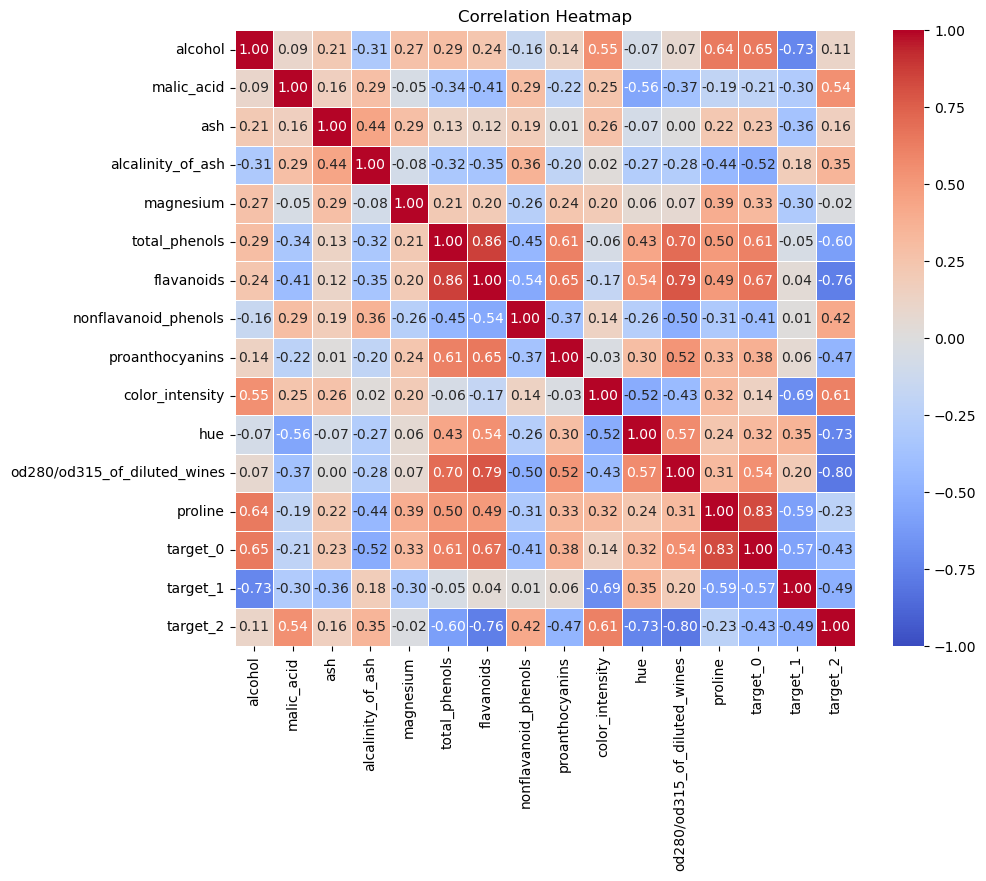

In [35]:
import seaborn as sns

matrix = df_wine.corr(method="pearson")

plt.figure(figsize=(10,8))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


Auch hier keine direkt ablesbaren Zusammenhänge zwischen Gruppen und Merkmalen.  
Auffällig hier ist aber z.B. der Zusammenhang zwischen "flavanoids" und Zielgruppe 0 & 2 oder dem Einfluss des "proline" Wertes auf die Gruppen 0 & 1.

## Farbverteilung

Ein naiver Versuch: vielleicht lassen sich die Weine ja einzig und allein an der Farbe kategorisieren?  
Dazu werden "hue" und "color_intensity" aufgezeichnet und die Punkte dann entsprechend der "Target_x" Werte eingefärbt.

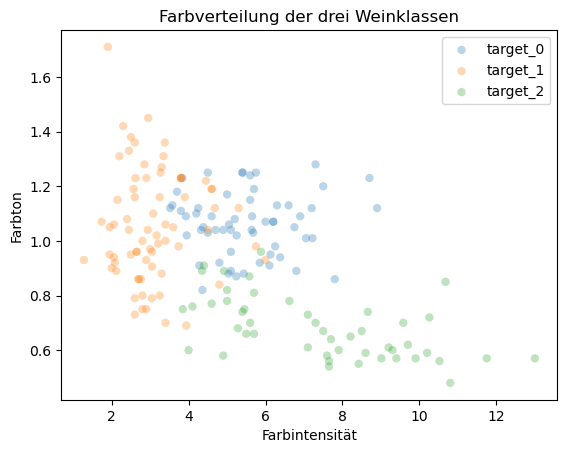

In [36]:
fig, ax = plt.subplots()

target_cols = ["target_0", "target_1", "target_2"]

for target in target_cols:
    subset = df_wine.loc[df_wine[target] == 1]
    ax.scatter(
        subset["color_intensity"],
        subset["hue"],
        label=f"{target}",
        alpha=0.3,
        edgecolors="none"
    )

ax.set_title("Farbverteilung der drei Weinklassen")
ax.set_xlabel("Farbintensität")
ax.set_ylabel("Farbton")
ax.legend()
plt.show()


Man sieht, dass die Gruppen tatsächlich farblich nah beieinander liegen. An den Übergangsstellen ist die Zuordnung aber ohne klare Linien und überhaupt sind die Cluster nur wirklich durch das Färben der Punkte trennbar.

## Standardskalierung

Um die einzelnen Features besser mit einander vergleichen zu können, werden sie im Folgenden mit dem Standardscaler skaliert. Da die Einheiten der einzelnen Features unbekannt sind und die Wertebereiche sich aber unterscheiden, ist es sinnvoll, die Daten zu skalieren, bevor man weitere Berechnungen durchführt. So bekommt jedes Feature gleichermaßen Bedeutung und kleine Wertebereiche werden nicht von größeren Überschattet.

In [37]:
from sklearn.preprocessing import StandardScaler

# Features ohne target
X = df_wine.drop(columns=["target_0", "target_1", "target_2"])

# Skalieren
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Clustering und PCA

Nun soll das Clustering mit kMeans und die Anwendung von PCA ausprobiert werden. 

PCA ist ein Verfahren zum Reduzieren der Dimensionen und ist fehlerbehaftet. Die Varianz, also quasi der Wertebereich, der durch die PCA-"Vereinfachungen" nicht mehr abgedeckt wird, beträgt etwa 44.5 % (siehe Darstellung). Es nutzt Zusammenhänge zwischen Features um Dimensionen einzusparen. So lassen sich auch höherdimensionale Abhängigkeiten in zwei Dimensionen darstellen und die Berechnungen werden auch einfacher.

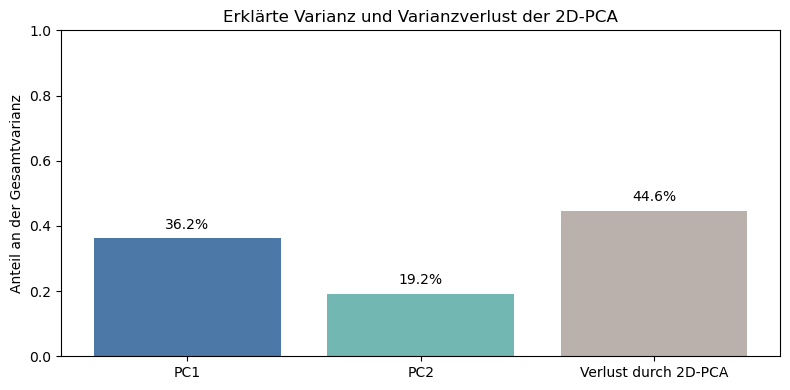

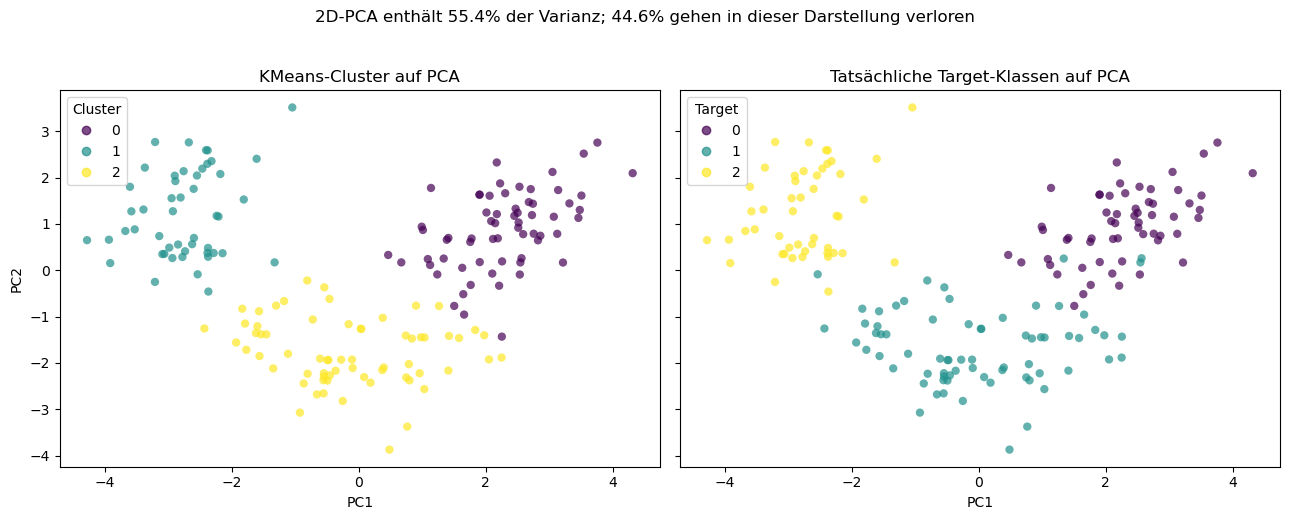

KMeans-Cluster,0,1,2
Target,,,
0,59,0,0
1,5,1,65
2,0,48,0


In [38]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA zum Darstellen in zwei Dimensionen
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
retained_variance = explained_variance.sum()
lost_variance = 1 - retained_variance

# Visualisierung: Wie viel Varianz bleibt in der 2D-PCA erhalten?
fig, ax = plt.subplots(figsize=(8, 4))
variance_labels = ["PC1", "PC2", "Verlust durch 2D-PCA"]
variance_values = [explained_variance[0], explained_variance[1], lost_variance]
bar_colors = ["#4c78a8", "#72b7b2", "#bab0ac"]

bars = ax.bar(variance_labels, variance_values, color=bar_colors)
ax.set_title("Erklärte Varianz und Varianzverlust der 2D-PCA")
ax.set_ylabel("Anteil an der Gesamtvarianz")
ax.set_ylim(0, 1)

for bar, value in zip(bars, variance_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.1%}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# KMeans auf den PCA-Koordinaten
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_pca)

# Die bekannten Klassen werden nur zur Gegenüberstellung genutzt, nicht fürs Clustering.
target_cols = ["target_0", "target_1", "target_2"]
target_labels = df_wine[target_cols].idxmax(axis=1).str.replace("target_", "", regex=False).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

cluster_plot = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pred,
    cmap="viridis",
    alpha=0.7,
    edgecolors="none"
)
axes[0].set_title("KMeans-Cluster auf PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(*cluster_plot.legend_elements(), title="Cluster")

target_plot = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=target_labels,
    cmap="viridis",
    alpha=0.7,
    edgecolors="none"
)
axes[1].set_title("Tatsächliche Target-Klassen auf PCA")
axes[1].set_xlabel("PC1")
axes[1].legend(*target_plot.legend_elements(), title="Target")

plt.suptitle(
    f"2D-PCA enthält {retained_variance:.1%} der Varianz; "
    f"{lost_variance:.1%} gehen in dieser Darstellung verloren",
    y=1.03
)
plt.tight_layout()
plt.show()

pd.crosstab(
    pd.Series(target_labels, name="Target"),
    pd.Series(y_pred, name="KMeans-Cluster")
)


Die 2D-PCA reduziert den Datensatz auf zwei Achsen. Das macht die Cluster gut sichtbar, bedeutet aber auch Informationsverlust: Ein Teil der ursprünglichen Varianz steckt nicht mehr in der Darstellung.

Die Gegenüberstellung zeigt links die von kMeans berechneten Cluster und rechts die tatsächlichen Target-Klassen. Die Farben sind dabei getrennt zu interpretieren, weil Cluster-IDs beliebig vergeben werden. Trotzdem sieht man, dass die berechneten Gruppen gut zu den bekannten Klassen passen.

## Hierarchisches Clustering

Mit Beispielcode zur Visualisierung von: [scikit-learn.org](https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html#sphx-glr-auto-examples-cluster-plot-agglomerative-dendrogram-py)

Nun soll hierarchisches Clustering getestet werden. Ziel ist auch hier das Sichtbarmachen von Clustern, insbesondere die Anzahl der vorhandenen Cluster lässt gut ablesen. 

Im Folgenden wird ein Baum mit Hierarchischem Clustering auf Basis der PCA-Werte erzeugt und mittels dem verlinkten Code dargestellt. 

In [39]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


Mit dem folgenden Code können wir dann den Baum berechnen und anzeigen lassen. Dieser wird hier nur bis zu einer Tiefe von 5 gezeichnet, um lesbarer zu bleiben. Die Distanzen unter den tiefer liegenden Ästen sind aber allesamt noch kleiner als die hier dargestellten.  

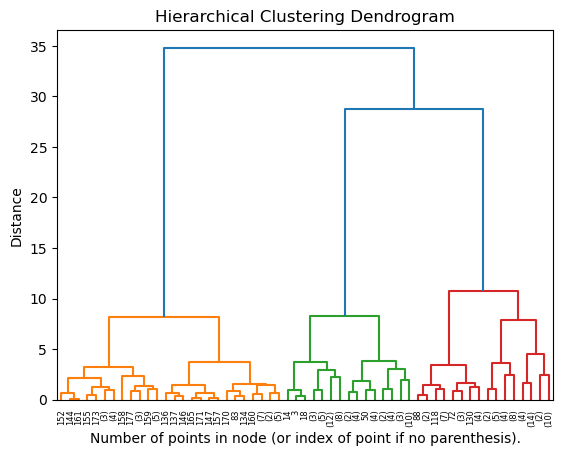

In [40]:
# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X_pca)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top 5 levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance")
plt.show()


Hier zeigt sich auch ganz eindeutig die drei-Geteiltheit des Datensatzes. Die Farben werden nach den berechneten Clustern gewählt, nicht nach den tatsächlichen Ziel-gruppen. 

Die drei Klassen haben sehr große Distanzen zueinander, wobei die Distanzen von Datenpunkten innerhalb einer Klasse sehr klein sind.

Wäre unbekannt, dass die Daten in drei Gruppen gehören, könnte man das mit dieser Darstellung sehr gut herausfinden.